In [1]:
import pwr_rei_template as pwr
import openmc
import openmc.deplete
import numpy as np
import copy
import pickle as pkl


In [ ]:

class Regression():
  def __init__():
    pass

  def normalize_res(self, res: dict, val: float):
    """normalizes res dictionary to some value"""
    for key in res.keys():
      the_sum = np.sum(res[key])
      if the_sum == 0:
        res[key] = res[key]
      else:
        res[key] = res[key] / the_sum * val
    return res


  def _get_vij(self, N: int, start: int, F: list, I: list,
              i: int, j: int, f: int):
    Vij = 0.0
    for k in range(start,start+N):
      Vij += (F[i][k][f] - I[i][f])*(F[j][k][f] - I[j][f]) / (N-1)
    return Vij

  def get_new_I(self, N: int, start: int,
                F: list, I: list,
                f: int):
    """
    Parameters
    ==========
    N : int
      number active histories

    start : int
      starting aka nSkipped

    F : list
      list of res dicts (F1, F2, F3, ...)

    I : list
      list of final I values (normalized?)

    f : int
      tally id number to operate on.

    Returns
    =======
    new_I : float
      the new value of I corresponding to tally id f
    coeff : float
      the correlation coefficient

    """
    n = len(F)
    V = np.zeros((n,n))
    for i in range(n):
      for j in range(n):
        V[i,j] = self._get_vij(N=N, start=start, F=F, I=I, i=i, j=j, f=f) # returns vectror of Vij where each index is a fuel zone

    print("the matrix V is")
    print(V)
    if n == 2:
      # print correlation a and b
      coeff = V[1,0]/V[0,0]**0.5/V[1,1]**0.5
      print("the correlation coeff = ", coeff)
    else:
      coeff = 0
    the_I = np.array([[this[f] for this in I]]).transpose() # col vec of my best estimates.
    X = np.ones((n,1)) # col vec of ones.
    M = np.linalg.inv(X.transpose() @ np.linalg.inv(V) @ X) @ X.transpose() @ np.linalg.inv(V)
    print("\nThe matrix is: ", M, "\n")
    new_I = M @ the_I
    return new_I, coeff

def run_transport_for_chain(model: openmc.Model, chain_file: str):
  """runs an openmc transport calculation for getting the depletion chain"""
  able_mats = depletable_mats_from_model(model) # get the depletable materials (so we can tally)
  fluxes, micros = openmc.deplete.get_microxs_and_flux(model, able_mats, chain_file=chain_file)
  return fluxes, micros

def run_transport(model: openmc.Model, power_tally_ids: list):
  """runs an openmc transport calculation while doing batch-by-patch tallies"""
  model.export_to_xml()
  res = {} # contains/stores power tally ids and stuff like that.
  settings = model.settings

  openmc.lib.init()
  openmc.lib.simulation_init()
  for b in range(settings.batches):
    tallies = [openmc.lib.tallies[the_id] for the_id in power_tally_ids]
    openmc.lib.next_batch()
    results = [tally.results for tally in tallies]
    res[b] = copy.deepcopy(results)
  openmc.lib.simulation_finalize()
  openmc.lib.finalize()
  return res

def depletable_mats_from_model(model: openmc.Model) -> openmc.Materials:
  """get depletable materials as openmc.Materials object"""
  depletable_mats = []
  for this in model.materials:
    if this.depletable:
      depletable_mats.append(this)
  depletable_mats = openmc.Materials(depletable_mats)
  return depletable_mats

def get_nuclides_for_transport(chain_file: str, model: openmc.Model):
  from openmc.deplete.coupled_operator import _find_cross_sections, _get_nuclides_with_data
  from openmc.deplete.chain import Chain
  chain = Chain.from_xml(chain_file)
  cross_sections = _find_cross_sections(model)
  nuclides_with_data = _get_nuclides_with_data(cross_sections)
  nuclides = [nuc.name for nuc in chain.nuclides
              if nuc.name in nuclides_with_data]
  return nuclides

def make_transport_material_library(output_name: str, model: openmc.Model, chain_file: str):
  """
  Function to take in a model, chain, and reults file.

  Updates the model.materials to be the transport materials
  with the latest results from results file. Inline modification

  Only considers transport nuclides though.
  """

  # Make transport material library.
  results = openmc.deplete.Results(output_name)
  transport_mats = []

  # Depletables
  trans_nuc_list = get_nuclides_for_transport(chain_file=chain_file, model=model)
  for mat in model.materials:
    if not mat.depletable:
      continue # skip if not depletable

    # Make a new material for the depletables
    new_mat = openmc.Material(mat.id, mat.name, temperature=mat.temperature)
    new_mat.volume = mat.volume
    new_mat.depletable = True
    for nuc in trans_nuc_list:
      perc = results.get_atoms(mat=mat, nuc=nuc, nuc_units='atom/b-cm')[-1][-1]
      new_mat.add_nuclide(nuclide=nuc, percent=perc, percent_type='ao')
      new_mat.set_density(units='sum')
    transport_mats.append(new_mat)

  # Nondepletables, can just append what we have already
  for mat in model.materials:
    if not mat.depletable:
      transport_mats.append(mat)

  new_lib = openmc.Materials(transport_mats)
  # new_lib.export_to_xml()
  model.materials = new_lib

def get_depletion_materials_from_results_EOS(output_name: str, model: openmc.Model):
  """
  Function for getting materials for depletion EOS values (or BOS for the next step)
  Returns a list of materials marked depletable
  with full depletion chain.

  No inline modification of models object.
  """
  results = openmc.deplete.Results(output_name)
  depletion_mat_list = []
  for mat in model.materials:
    if mat.depletable:
      eos_mat = results[-1].get_material(str(mat.id))
      depletion_mat_list.append(eos_mat)
  return openmc.Materials(depletion_mat_list)

[ 11.4375  34.3125  57.1875  80.0625 102.9375 125.8125 148.6875 171.5625
 194.4375 217.3125 240.1875 263.0625 285.9375 308.8125 331.6875 354.5625]


/home/jonathon/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/stats/multivariate.py:829: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

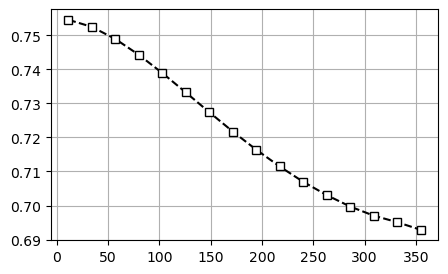

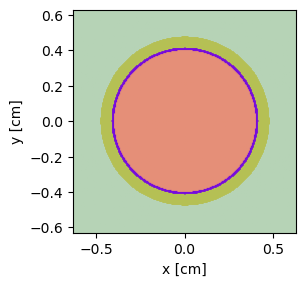

In [ ]:
"""some random settings"""
fuel_r=0.3975
power_density = 104
power = power_density * 366  * np.pi * fuel_r**2
dt = [0.5, 1, 1.5, 2, 5, 10, 20] # up to 20 days

"""get the model"""
model = pwr.get_model()
chain_file = '../chain_casl_pwr.xml'

"""get depletable mats as a Materials object"""


"""run T0"""
depletion_materials = depletable_mats_from_model(model=model) # get from starting model
for idx, this_dt in enumerate(dt):
  # res = run_transport_for_chain(model)## this one for res tracking...

  # Get fluxes and xs from transport
  fluxes, micro_xs = run_transport_for_chain(model=model, chain_file=chain_file)

  # Deplete (operator setup and then deplete)
  output_name = f"depl_step_{idx}.h5"
  op = openmc.deplete.IndependentOperator(depletion_materials, fluxes, micro_xs, chain_file=chain_file)
  openmc.deplete.PredictorIntegrator(op, timesteps=[this_dt], power=power, timestep_units='d').integrate(path=output_name)

  # Now update the transport materials (inline modify model.materials)
  make_transport_material_library(output_name=output_name, model=model, chain_file=chain_file)

  # Now make the depletion materials BOS
  depletion_materials = get_depletion_materials_from_results_EOS(output_name=output_name, model=model)

fluxes, micro_xs = run_transport_for_chain(model=model, chain_file=chain_file)
with open('FINAL.pkl', 'wb') as f:
  pkl.dump((fluxes, micro_xs), f)




In [ ]:
"""opening pickle file and getting xs"""
# with open('openmc_RIE/chain_gen/micros.pkl', 'rb') as file:
#   flux_fake, micro_xs = pkl.load(file)

"""setup operator"""
op = openmc.deplete.IndependentOperator(depletable_mats, fluxes, micro_xs, chain_file=chain_file)

"""perform depletion"""
output_name = f'step0_depl.h5'
intr = openmc.deplete.PredictorIntegrator(op, timesteps=[10], power=power, timestep_units='d')
intr.integrate(output=output_name)



In [ ]:
"""get output"""
results = openmc.deplete.Results(output_name)
results.export_to_materials(burnup_index=-1, nuc_with_data=get_nuclides_for_transport(chain_file, model))



In [ ]:
results.